In [ ]:
# ── CELL 1: Install Dependencies ─────────────────────────────
!pip install pyswarms imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
# ── CELL 2: Imports ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import pyswarms as ps
from pyswarms.discrete import BinaryPSO

warnings.filterwarnings("ignore")
np.random.seed(42)
print("✅ All libraries loaded.")


✅ All libraries loaded.


In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

print(f"Dataset shape: {df.shape}")
print(df.head(3))


Saving weatherAUS.csv to weatherAUS.csv
Dataset shape: (145460, 23)
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7       1007.1       8.0       NaN     16.9     21.8         No   
1       1010.6       1007.8       NaN       NaN     17.2     24.3         No   
2       1007.6       1008.7       NaN       2.0     21.0     23.2         No   

   RainTo

In [ ]:
# ── CELL 4: Preprocessing ────────────────────────────────────
# 4a. Drop rows where target is missing
df.dropna(subset=['RainTomorrow'], inplace=True)

# 4b. Cyclic month encoding from Date
df['Date'] = pd.to_datetime(df['Date'])
df['Month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)
df.drop(columns=['Date'], inplace=True)

# 4c. Drop Location (too many categories; not useful without encoding strategy)
df.drop(columns=['Location'], inplace=True)

# 4d. Encode binary categoricals
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# 4e. Encode wind direction columns
wind_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
le = LabelEncoder()
for col in wind_cols:
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))

# 4f. Fill remaining numeric nulls with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f"After preprocessing: {df.shape}")
print(f"Class distribution:\n{df['RainTomorrow'].value_counts()}")


After preprocessing: (142193, 23)
Class distribution:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


In [ ]:
# ── CELL 5: Feature/Target Split + Scaling ───────────────────
X = df.drop(columns=['RainTomorrow']).values
y = df['RainTomorrow'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_names = df.drop(columns=['RainTomorrow']).columns.tolist()
print(f"Total features: {len(feature_names)}")
print(f"Features: {feature_names}")

Total features: 22
Features: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Month_sin', 'Month_cos']


In [ ]:
# ── CELL 6: Baseline LR (All Features, 5-Fold CV) ───────────
print("\n⏳ Running Baseline LR (all features)...")

lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', random_state=42)

pipeline_base = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', lr_base)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Collect metrics across folds
base_metrics = {'acc': [], 'f1': [], 'prec': [], 'rec': [], 'auc': []}

for train_idx, test_idx in skf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    pipeline_base.fit(X_tr, y_tr)
    y_pred = pipeline_base.predict(X_te)
    y_prob = pipeline_base.predict_proba(X_te)[:, 1]

    base_metrics['acc'].append(accuracy_score(y_te, y_pred))
    base_metrics['f1'].append(f1_score(y_te, y_pred))
    base_metrics['prec'].append(precision_score(y_te, y_pred))
    base_metrics['rec'].append(recall_score(y_te, y_pred))
    base_metrics['auc'].append(roc_auc_score(y_te, y_prob))

print("\n📊 Baseline LR Results (Mean ± Std across 5 folds):")
for k, v in base_metrics.items():
    print(f"  {k.upper():<6}: {np.mean(v):.4f} ± {np.std(v):.4f}")




⏳ Running Baseline LR (all features)...


KeyboardInterrupt: 

In [ ]:
# ── CELL 7: PSO Feature Selection ────────────────────────────
SAMPLE_SIZE = 20000

idx_sample = []
for cls in [0, 1]:
    cls_idx = np.where(y == cls)[0]
    n = int(SAMPLE_SIZE * (len(cls_idx) / len(y)))
    idx_sample.extend(np.random.choice(cls_idx, n, replace=False))

X_sample = X_scaled[idx_sample]
y_sample = y[idx_sample]

print(f"PSO fitness sample size: {len(X_sample)}")
print(f"Sample class distribution: {np.bincount(y_sample)}")

# Fitness function: minimise negative F1 (with SMOTE + LR inside)
def pso_fitness(particles):
    """
    particles: (n_particles, n_features) binary matrix
    returns: (n_particles,) cost array
    """
    costs = []
    for particle in particles:
        selected = np.where(particle == 1)[0]

        # Ensure at least 3 features selected
        if len(selected) < 3:
            costs.append(1.0)  # worst cost
            continue

        X_sel = X_sample[:, selected]

        lr = LogisticRegression(max_iter=300, class_weight='balanced',
                                solver='saga', random_state=42)
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('lr', lr)
        ])

        skf_pso = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        f1_scores = []

        for tr, te in skf_pso.split(X_sel, y_sample):
            pipeline.fit(X_sel[tr], y_sample[tr])
            y_pred = pipeline.predict(X_sel[te])
            f1_scores.append(f1_score(y_sample[te], y_pred, zero_division=0))

        costs.append(1 - np.mean(f1_scores))  # minimise

    return np.array(costs)


# PSO parameters
N_PARTICLES = 30
N_ITERATIONS = 100
N_FEATURES = X_scaled.shape[1]

options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 3, 'p': 2}

print(f"\n⏳ Running Binary PSO ({N_PARTICLES} particles, {N_ITERATIONS} iterations)...")
print("This may take several minutes — grab water 💧\n")

optimizer = BinaryPSO(n_particles=N_PARTICLES,
                      dimensions=N_FEATURES,
                      options=options)

cost_history, best_pos = optimizer.optimize(pso_fitness, iters=N_ITERATIONS, verbose=True)

selected_features = np.where(best_pos == 1)[0]
selected_names = [feature_names[i] for i in selected_features]

print(f"\n✅ PSO done!")
print(f"Selected {len(selected_features)} / {N_FEATURES} features:")
print(selected_names)



In [ ]:
# ── CELL 8: PSO+LR Training & Evaluation (5-Fold CV) ─────────
print("\n⏳ Running PSO+LR on selected features (5-fold CV)...")

X_pso = X_scaled[:, selected_features]

lr_pso = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', random_state=42)

pipeline_pso = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', lr_pso)
])

pso_metrics = {'acc': [], 'f1': [], 'prec': [], 'rec': [], 'auc': []}

for train_idx, test_idx in skf.split(X_pso, y):
    X_tr, X_te = X_pso[train_idx], X_pso[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    pipeline_pso.fit(X_tr, y_tr)
    y_pred = pipeline_pso.predict(X_te)
    y_prob = pipeline_pso.predict_proba(X_te)[:, 1]

    pso_metrics['acc'].append(accuracy_score(y_te, y_pred))
    pso_metrics['f1'].append(f1_score(y_te, y_pred))
    pso_metrics['prec'].append(precision_score(y_te, y_pred))
    pso_metrics['rec'].append(recall_score(y_te, y_pred))
    pso_metrics['auc'].append(roc_auc_score(y_te, y_prob))

print("\n📊 PSO+LR Results (Mean ± Std across 5 folds):")
for k, v in pso_metrics.items():
    print(f"  {k.upper():<6}: {np.mean(v):.4f} ± {np.std(v):.4f}")


In [ ]:
# ── CELL 9: Results Comparison Table ─────────────────────────
metrics_labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'AUC-ROC']
keys = ['acc', 'f1', 'prec', 'rec', 'auc']

results_df = pd.DataFrame({
    'Metric': metrics_labels,
    'Baseline LR': [f"{np.mean(base_metrics[k]):.4f}" for k in keys],
    'PSO + LR':    [f"{np.mean(pso_metrics[k]):.4f}" for k in keys],
})

print("\n📋 Final Comparison:")
print(results_df.to_string(index=False))

print(f"\n📌 Features used — Baseline LR: {N_FEATURES} | PSO+LR: {len(selected_features)}")
print(f"📌 Feature reduction: {((N_FEATURES - len(selected_features)) / N_FEATURES * 100):.1f}%")



NameError: name 'metrics_labels' is not defined

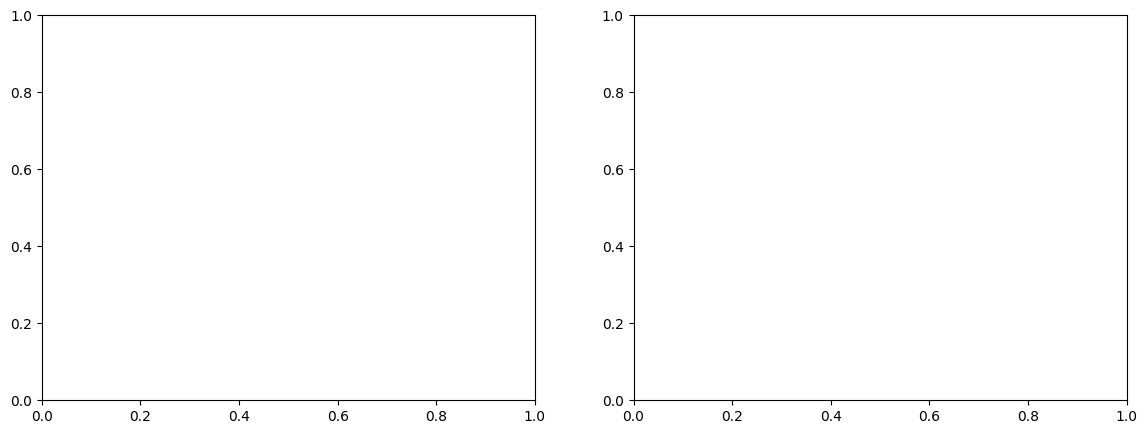

In [ ]:
# ── CELL 10: Plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: metric comparison
x = np.arange(len(metrics_labels))
width = 0.35
base_vals = [np.mean(base_metrics[k]) for k in keys]
pso_vals  = [np.mean(pso_metrics[k]) for k in keys]

axes[0].bar(x - width/2, base_vals, width, label='Baseline LR', color='steelblue')
axes[0].bar(x + width/2, pso_vals,  width, label='PSO + LR',    color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels, rotation=15)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Baseline LR vs PSO+LR — Performance Comparison')
axes[0].legend()
axes[0].set_ylabel('Score')

# PSO convergence curve
axes[1].plot(optimizer.cost_history, color='darkorange', linewidth=2)
axes[1].set_title('PSO Convergence Curve')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Best Cost (1 - F1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pso_lr_results.png', dpi=150)
plt.show()
print("✅ Plot saved as pso_lr_results.png")



In [ ]:
# ── CELL 11: Confusion Matrices ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Retrain on 80% / test on 20% for confusion matrix display
from sklearn.model_selection import train_test_split

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_scaled, y, test_size=0.2,
                                                     stratify=y, random_state=42)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_pso,    y, test_size=0.2,
                                                     stratify=y, random_state=42)

pipeline_base.fit(X_tr_b, y_tr_b)
pipeline_pso.fit(X_tr_p, y_tr_p)

for ax, pipe, X_te, y_te, title in [
    (axes[0], pipeline_base, X_te_b, y_te_b, 'Baseline LR'),
    (axes[1], pipeline_pso,  X_te_p, y_te_p, 'PSO + LR'),
]:
    cm = confusion_matrix(y_te, pipe.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Rain', 'Rain'],
                yticklabels=['No Rain', 'Rain'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices saved.")



In [ ]:
# ── CELL 12: Save Artifacts ───────────────────────────────────
os.makedirs('artifacts', exist_ok=True)

joblib.dump(pipeline_base,    'artifacts/baseline_lr_pipeline.pkl')
joblib.dump(pipeline_pso,     'artifacts/pso_lr_pipeline.pkl')
joblib.dump(scaler,           'artifacts/scaler.pkl')
joblib.dump(selected_features,'artifacts/selected_features.pkl')
joblib.dump(feature_names,    'artifacts/feature_names.pkl')
joblib.dump(selected_names,   'artifacts/selected_names.pkl')
joblib.dump(base_metrics,     'artifacts/base_metrics.pkl')
joblib.dump(pso_metrics,      'artifacts/pso_metrics.pkl')

print("✅ All artifacts saved to /artifacts/")
print("Download them from the Colab file browser → right-click → Download")



In [ ]:
import shutil
from google.colab import files

shutil.make_archive('artifacts', 'zip', 'artifacts')
files.download('artifacts.zip')

In [ ]:
# ── FIX CELL: Save missing artifacts ─────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Confusion matrices
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_pso,    y, test_size=0.2, stratify=y, random_state=42)

pipeline_base.fit(X_tr_b, y_tr_b)
pipeline_pso.fit(X_tr_p,  y_tr_p)

base_cm = confusion_matrix(y_te_b, pipeline_base.predict(X_te_b))
pso_cm  = confusion_matrix(y_te_p, pipeline_pso.predict(X_te_p))

joblib.dump(base_cm,               'artifacts/base_cm.pkl')
joblib.dump(pso_cm,                'artifacts/pso_cm.pkl')
joblib.dump(optimizer.cost_history,'artifacts/cost_history.pkl')

print("✅ Missing artifacts saved!")

# Re-download
import shutil
from google.colab import files
shutil.make_archive('artifacts', 'zip', 'artifacts')
files.download('artifacts.zip')

Upload your artifacts.zip now...


Saving artifacts (2).zip to artifacts (2) (1).zip
✅ Artifacts extracted
['cost_history.pkl', 'pso_cm.pkl', 'pso_lr_pipeline.pkl', 'feature_names.pkl', 'pso_metrics.pkl', 'selected_features.pkl', 'scaler.pkl', 'baseline_lr_pipeline.pkl', 'base_metrics.pkl', 'base_cm.pkl', 'selected_names.pkl']
✅ All artifacts loaded


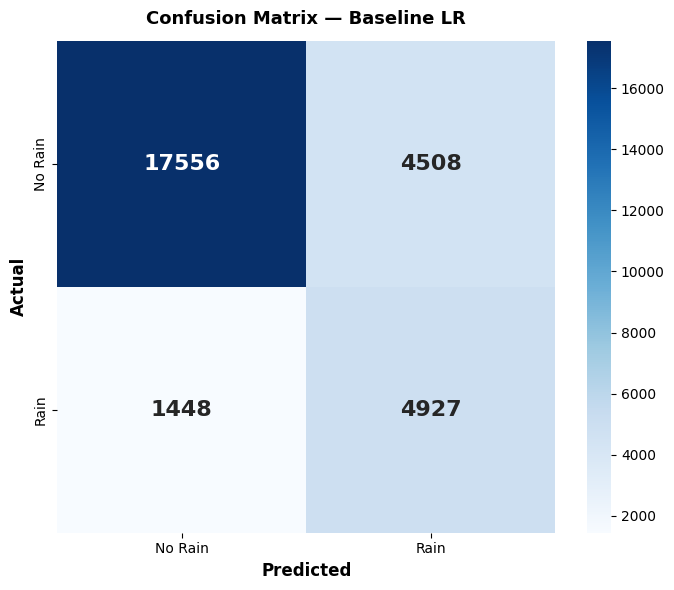

✅ Saved figure_4_2_cm_baseline.png


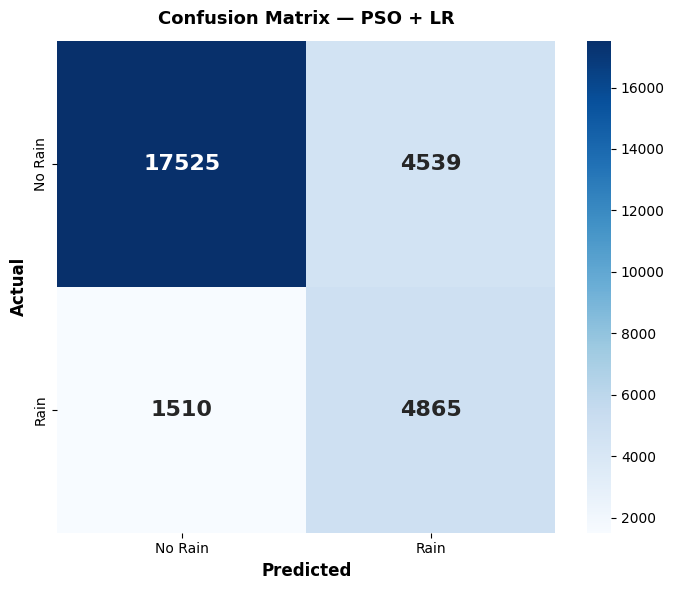

✅ Saved figure_4_5_cm_pso.png


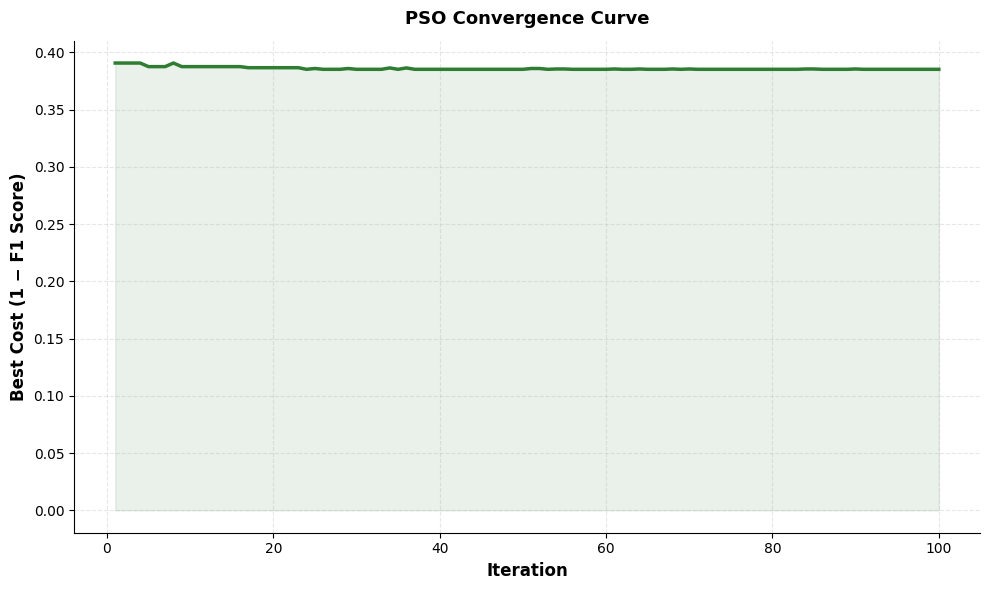

✅ Saved figure_4_3_convergence.png


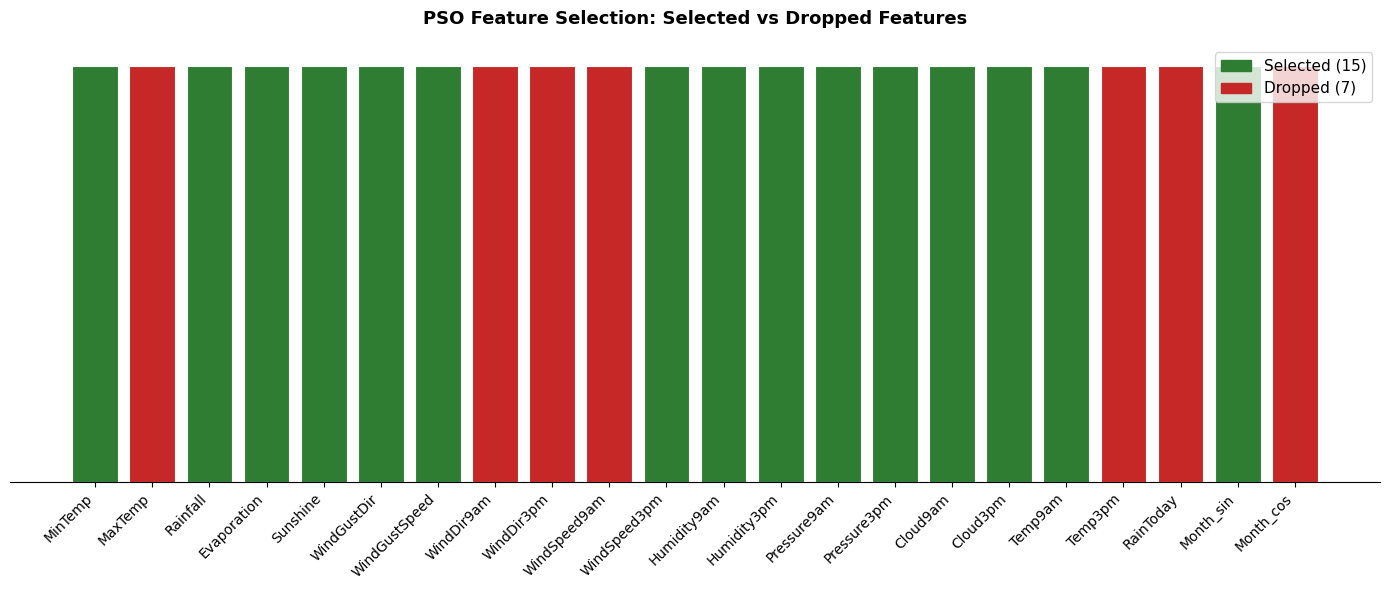

✅ Saved figure_4_4_features.png


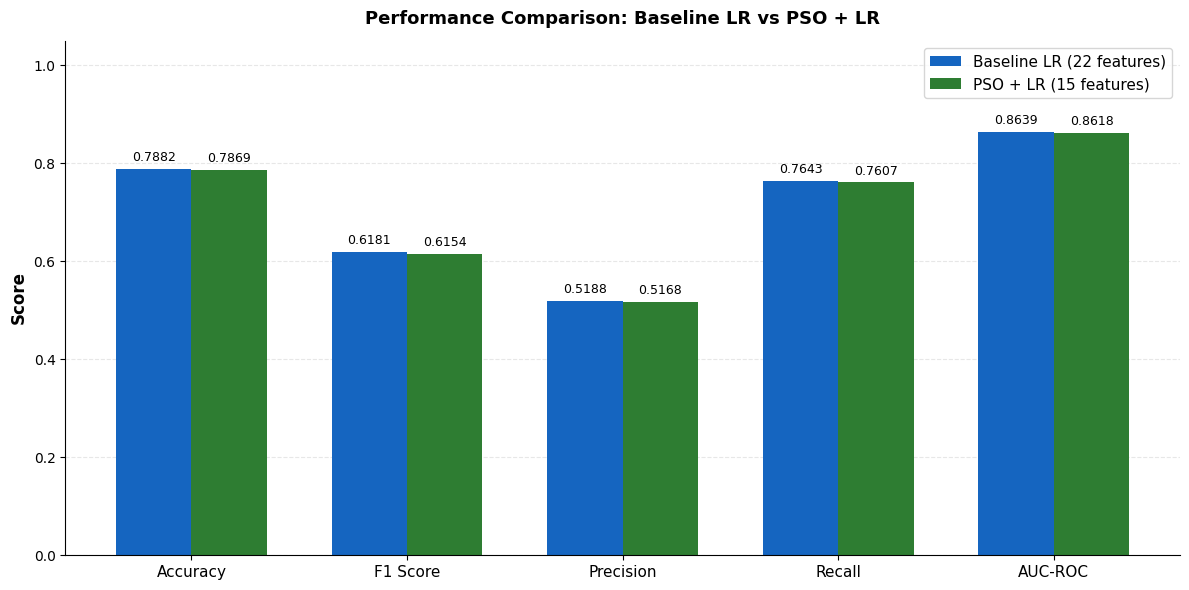

✅ Saved figure_4_6_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL FIGURES REGENERATED AND DOWNLOADED as figures.zip
Note: Figure 4.1 (class distribution) needs the raw dataset — run figure_4_1_code.py separately after loading the CSV


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE REGENERATION FROM SAVED ARTIFACTS
# Run this in a fresh Colab runtime — no PSO/training rerun needed
# ══════════════════════════════════════════════════════════════════════════

# ── STEP 1: Upload artifacts.zip ──────────────────────────────────────────
from google.colab import files
import zipfile, os

print("Upload your artifacts.zip now...")
uploaded = files.upload()

# Unzip
with zipfile.ZipFile('artifacts (2).zip', 'r') as z:
    z.extractall('artifacts')
print("✅ Artifacts extracted")
print(os.listdir('artifacts'))


# ── STEP 2: Load everything ───────────────────────────────────────────────
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

base = 'artifacts'
feature_names   = joblib.load(f'{base}/feature_names.pkl')
selected_names  = joblib.load(f'{base}/selected_names.pkl')
base_metrics    = joblib.load(f'{base}/base_metrics.pkl')
pso_metrics     = joblib.load(f'{base}/pso_metrics.pkl')
base_cm         = joblib.load(f'{base}/base_cm.pkl')
pso_cm          = joblib.load(f'{base}/pso_cm.pkl')
cost_history    = joblib.load(f'{base}/cost_history.pkl')
print("✅ All artifacts loaded")


# ── FIGURE 4.2 & 4.5: Confusion Matrices ──────────────────────────────────
for cm, name, fname in [(base_cm, 'Baseline LR', 'figure_4_2_cm_baseline.png'),
                         (pso_cm, 'PSO + LR', 'figure_4_5_cm_pso.png')]:
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
                xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'],
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Saved {fname}")


# ── FIGURE 4.3: PSO Convergence Curve ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(cost_history) + 1), cost_history,
        color='#2e7d32', linewidth=2.5)
ax.fill_between(range(1, len(cost_history) + 1), cost_history,
                alpha=0.1, color='#2e7d32')
ax.set_title('PSO Convergence Curve', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Best Cost (1 − F1 Score)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figure_4_3_convergence.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved figure_4_3_convergence.png")


# ── FIGURE 4.4: PSO Selected vs Dropped Features ──────────────────────────
colors = ['#2e7d32' if f in selected_names else '#c62828' for f in feature_names]
dropped = [f for f in feature_names if f not in selected_names]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(feature_names, [1] * len(feature_names), color=colors,
       edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks([])
ax.set_title('PSO Feature Selection: Selected vs Dropped Features',
             fontsize=13, fontweight='bold', pad=15)
sel_patch = mpatches.Patch(color='#2e7d32', label=f'Selected ({len(selected_names)})')
drop_patch = mpatches.Patch(color='#c62828', label=f'Dropped ({len(dropped)})')
ax.legend(handles=[sel_patch, drop_patch], fontsize=11, loc='upper right')
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig('figure_4_4_features.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved figure_4_4_features.png")


# ── FIGURE 4.6: Performance Comparison Bar Chart ──────────────────────────
keys = ['acc', 'f1', 'prec', 'rec', 'auc']
labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'AUC-ROC']
base_vals = [np.mean(base_metrics[k]) for k in keys]
pso_vals  = [np.mean(pso_metrics[k]) for k in keys]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, base_vals, width, label='Baseline LR (22 features)', color='#1565c0')
b2 = ax.bar(x + width/2, pso_vals, width, label='PSO + LR (15 features)', color='#2e7d32')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison: Baseline LR vs PSO + LR',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=11)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.4f}',
                ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figure_4_6_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved figure_4_6_comparison.png")


# ── DOWNLOAD ALL FIGURES ──────────────────────────────────────────────────
import shutil
os.makedirs('figures', exist_ok=True)
for f in ['figure_4_2_cm_baseline.png', 'figure_4_3_convergence.png',
          'figure_4_4_features.png', 'figure_4_5_cm_pso.png',
          'figure_4_6_comparison.png']:
    shutil.move(f, f'figures/{f}')

shutil.make_archive('figures', 'zip', 'figures')
files.download('figures.zip')
print("\n✅ ALL FIGURES REGENERATED AND DOWNLOADED as figures.zip")
print("Note: Figure 4.1 (class distribution) needs the raw dataset — run figure_4_1_code.py separately after loading the CSV")

Upload weatherAUS.csv now...


Saving weatherAUS.csv to weatherAUS (1).csv


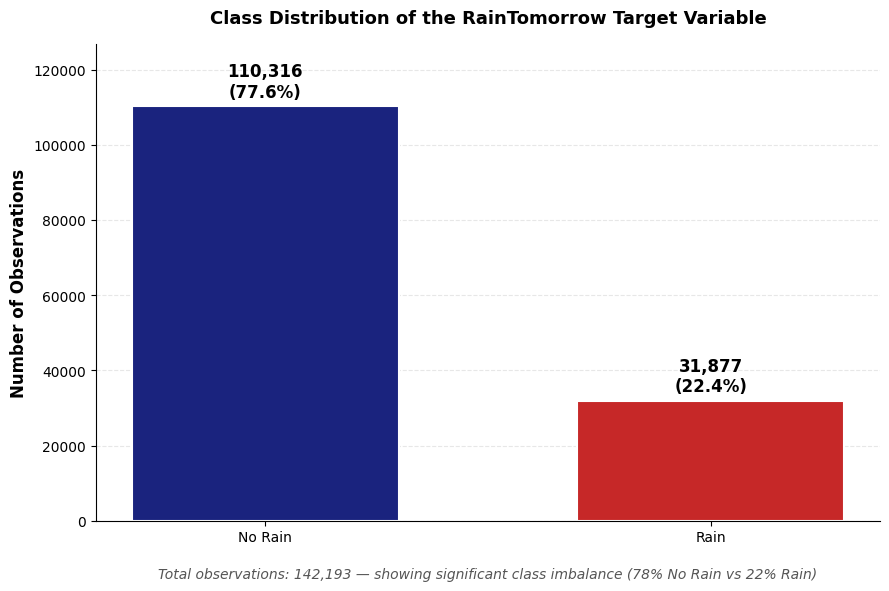

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Figure 4.1 saved and downloaded


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 4.1: Class Distribution of Target Variable
# Run this after uploading weatherAUS.csv fresh (runtime was lost)
# ══════════════════════════════════════════════════════════════════════════

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

# ── Upload the dataset ────────────────────────────────────────────────────
print("Upload weatherAUS.csv now...")
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# ── Drop missing targets (same as original preprocessing) ────────────────
df.dropna(subset=['RainTomorrow'], inplace=True)

# ── Count class distribution ──────────────────────────────────────────────
counts = df['RainTomorrow'].value_counts()
labels = ['No Rain', 'Rain']
values = [counts['No'], counts['Yes']]
total = sum(values)
percentages = [v / total * 100 for v in values]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(labels, values, color=['#1a237e', '#c62828'],
              edgecolor='white', linewidth=1.5, width=0.6)

for bar, val, pct in zip(bars, values, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + total * 0.01,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Observations', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution of the RainTomorrow Target Variable',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, max(values) * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

ax.text(0.5, -0.12,
        f'Total observations: {total:,} — showing significant class imbalance '
        f'({percentages[0]:.0f}% No Rain vs {percentages[1]:.0f}% Rain)',
        transform=ax.transAxes, ha='center', fontsize=10,
        color='#555555', style='italic')

plt.tight_layout()
plt.savefig('figure_4_1_class_dist.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

files.download('figure_4_1_class_dist.png')
print("✅ Figure 4.1 saved and downloaded")